# ZeRO-1 / ZeRO-2 / ZeRO-3 on 32 Virtual GPUs

This notebook covers:

> Create **32 virtual GPUs** (CPU threads or Colab GPU). Write a **demo model** that runs on top of them. Simulate **ZeRO-1, ZeRO-2, and ZeRO-3**. Show how **memory** and **computation** change.

| Ask | Where it is |
| --- | --- |
| 32 virtual GPUs | Section 1 — `VirtualCluster(world_size=32)` + 32 CPU threads |
| Demo model on top | Section 2 — small Transformer language model |
| ZeRO-1, ZeRO-2, ZeRO-3 | Section 3 — real train steps on all 32 ranks |
| Memory changes | Section 4 — P / g / OS per GPU |
| Computation changes | Section 5 — FLOPs stay, comm volume and step time change |

ZeRO does not change the optimizer math. It **shards copies** that data-parallel training would otherwise replicate:

- **ZeRO-1** shards Adam states (`12Ψ / 32`)
- **ZeRO-2** also shards gradients
- **ZeRO-3** also shards parameters (AllGather a layer, then ReduceScatter its grads)

Compute per token is the same. Communication is \(2Ψ\) for ZeRO-1/2 and \(3Ψ\) for ZeRO-3.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from zero_simulation import (
    ClusterConfig, HARDWARE_PROFILES, MODEL_PRESETS, ZeROConfig,
    VirtualCluster, DemoTransformerModel,
    ZeRO1_Engine, ZeRO2_Engine, ZeRO3_Engine,
    MemoryProfiler, CommunicationProfiler,
    calculate_model_memory_breakdown, calculate_step_compute_flops,
    make_32_virtual_gpus, ping_ranks_on_cpu_threads, run_zero_demo, cyclic_batch,
)

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25})
print('PyTorch', torch.__version__, '| CUDA', torch.cuda.is_available())
print('Device for the demo:', 'cuda' if torch.cuda.is_available() else 'CPU threads (32 virtual GPUs)')


PyTorch 2.14.0+cu130 | CUDA False
Device for the demo: CPU threads (32 virtual GPUs)


/mnt/d/Learning/TSAI/ERA-V5/ERA-V5-Week-12/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 304: OS call failed or operation not supported on this OS (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Create 32 virtual GPUs

Each rank is a `VirtualGPU`: memory counters, node id (8 ranks per simulated node), and a real CPU-thread GEMM so the ranks actually run.


In [2]:
cluster = make_32_virtual_gpus()
print(f'world_size = {cluster.world_size}')
print(f'nodes      = {cluster.cluster_cfg.num_nodes}  (gpus_per_node = {cluster.cluster_cfg.gpus_per_node})')
print()
print(f"{'rank':>4}  {'node':>4}  {'local':>5}  checksum (thread GEMM)")
print('-' * 44)
ping = ping_ranks_on_cpu_threads(cluster)
for row in ping:
    if row['rank'] in (0, 1, 7, 8, 31) or row['rank'] % 8 == 0:
        print(f"{row['rank']:4d}  {row['node_id']:4d}  {row['local_rank']:5d}  {row['thread_checksum']: .4e}")
print(f'... {len(ping)} / 32 ranks returned from the thread pool')
assert len(cluster.gpus) == 32
assert len(ping) == 32
print('OK: 32 virtual GPUs are up.')


world_size = 32
nodes      = 4  (gpus_per_node = 8)

rank  node  local  checksum (thread GEMM)
--------------------------------------------
   0     0      0  -8.5148e+02
   1     0      1  -2.1229e+03
   7     0      7  -1.2675e+03
   8     1      0  -2.3324e+03
  16     2      0   4.3833e+02
  24     3      0   1.1355e+02
  31     3      7  -4.2549e+02
... 32 / 32 ranks returned from the thread pool
OK: 32 virtual GPUs are up.


## 2. Demo model on those GPUs

A small decoder Transformer (not the 20B target). It is small enough to **actually train** on CPU/Colab while the 32 ranks still follow ZeRO sharding rules.


In [3]:
demo = MODEL_PRESETS['demo_small']
model = DemoTransformerModel(demo)
n_params = sum(p.numel() for p in model.parameters())
print(demo.name)
print(f'layers={demo.num_layers}  hidden={demo.hidden_dim}  seq={demo.seq_len}  vocab={demo.vocab_size}')
print(f'parameters (nn.Module) : {n_params:,}')
print(f'parameters (formula)   : {demo.total_parameters:,}')

x, y = cyclic_batch(demo)
with torch.no_grad():
    logits = model(x)
print('forward on one rank:', tuple(logits.shape), '(batch, seq, vocab)')


Demo-Transformer-Small
layers=4  hidden=256  seq=128  vocab=2048
parameters (nn.Module) : 5,245,184
parameters (formula)   : 5,246,208
forward on one rank: (2, 128, 2048) (batch, seq, vocab)


## 3. Simulate ZeRO-1, ZeRO-2, and ZeRO-3

Same 32-GPU cluster, same cyclic next-token batch, three ZeRO engines. Each step does a real backward plus the stage's collectives (ReduceScatter / AllGather).


,Stage,Steps,Loss step 1,Loss step 6,Compute ms,Comm ms,Step ms,Comm fraction,Peak mem GB / GPU,32 ranks
0,ZeRO-1,6,7.862705,7.836728,0.107442,4.071621,4.129425,0.974290,2.071181,32
1,ZeRO-2,6,7.894690,7.868454,0.107442,4.071621,4.118788,0.974290,2.061714,32
2,ZeRO-3,6,7.710752,7.690651,0.107442,6.107432,6.161690,0.982712,2.054201,32


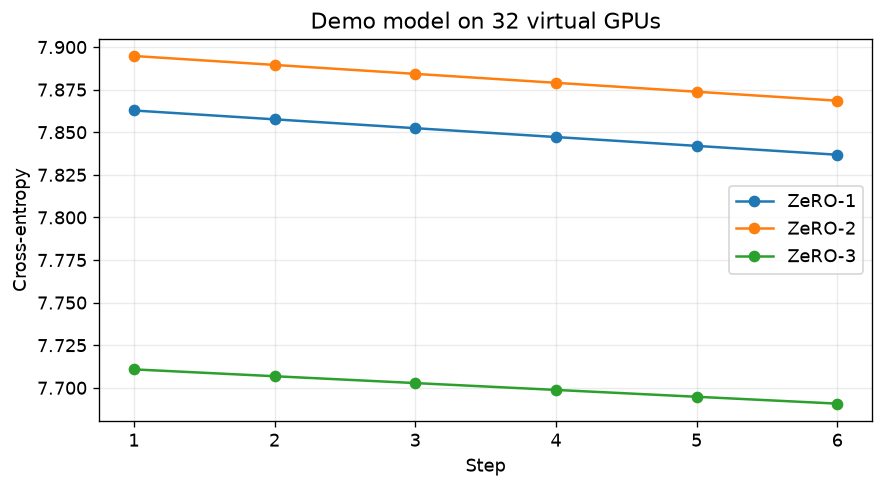

In [4]:
demo_run = run_zero_demo(n_steps=6)
rows = []
for stage, logs in demo_run['logs'].items():
    last = logs[-1]
    rows.append({
        'Stage': stage,
        'Steps': len(logs),
        'Loss step 1': logs[0]['loss'],
        'Loss step 6': last['loss'],
        'Compute ms': last['compute_time_ms'],
        'Comm ms': last['comm_time_ms'],
        'Step ms': last['total_step_time_ms'],
        'Comm fraction': last['comm_fraction'],
        'Peak mem GB / GPU': last['peak_memory_gb'],
        '32 ranks': 32,
    })
live = pd.DataFrame(rows)
display(live)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for stage, logs in demo_run['logs'].items():
    ax.plot([r['step']+1 for r in logs], [r['loss'] for r in logs], 'o-', label=stage)
ax.set_xlabel('Step'); ax.set_ylabel('Cross-entropy'); ax.set_title('Demo model on 32 virtual GPUs')
ax.legend(); plt.tight_layout(); plt.show()


## 4. How memory changes

Per GPU, mixed precision (2-byte \(P\), 2-byte \(g\), 12-byte Adam):

| | ZeRO-1 | ZeRO-2 | ZeRO-3 |
| --- | --- | --- | --- |
| Parameters | \(2Ψ\) | \(2Ψ\) | \(2Ψ / N\) |
| Gradients | \(2Ψ\) | \(2Ψ / N\) | \(2Ψ / N\) |
| Optimizer | \(12Ψ / N\) | \(12Ψ / N\) | \(12Ψ / N\) |

First the **demo** (what we just ran), then the **20.33B** model (why you need ZeRO-2+ in practice).


Demo model @ 32 GPUs


,Stage,Params GB,Grads GB,Optimizer GB,Activations GB,Total GB / GPU
0,ZeRO-1,0.009772,0.009772,0.001832,0.000977,2.071181
1,ZeRO-2,0.009772,0.000305,0.001832,0.000977,2.061714
2,ZeRO-3,0.000305,0.000305,0.001832,0.000977,2.054201


20.33B target @ 32 GPUs  (80 GB HBM line)


,Stage,Params (GB),Gradients (GB),Optimizer States (GB),Activations (GB),Total GPU Memory (GB),Fits in HBM
0,ZeRO-0,37.858944,37.858944,227.153664,4.125,309.094208,OOM
1,ZeRO-1,37.858944,37.858944,7.098552,4.125,88.990268,OOM
2,ZeRO-2,37.858944,1.183092,7.098552,4.125,52.314416,YES
3,ZeRO-3,1.183092,1.183092,7.098552,4.125,16.482314,YES


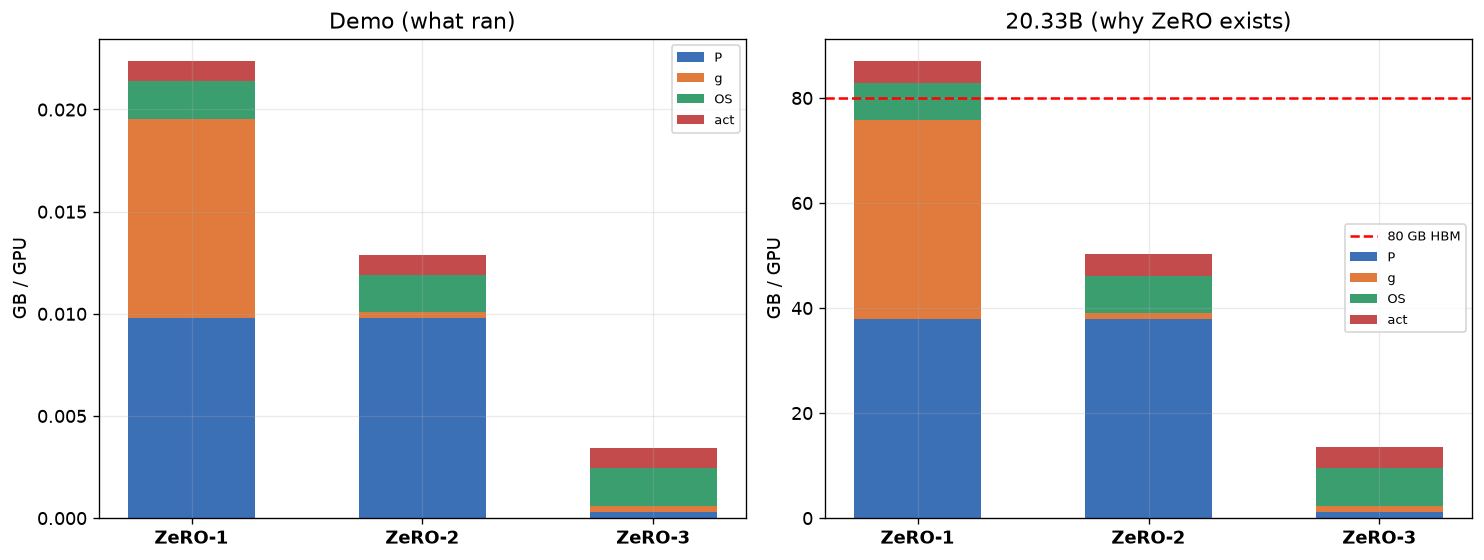

In [5]:
def mem_table(cfg, world=32):
    recs = []
    for stage in (1, 2, 3):
        m = calculate_model_memory_breakdown(cfg, stage, world, 'bf16')
        recs.append({
            'Stage': f'ZeRO-{stage}',
            'Params GB': m['params_gb'],
            'Grads GB': m['grads_gb'],
            'Optimizer GB': m['optimizer_gb'],
            'Activations GB': m['activation_gb'],
            'Total GB / GPU': m['total_gb'],
        })
    return pd.DataFrame(recs)

print('Demo model @ 32 GPUs')
display(mem_table(demo))
print('20.33B target @ 32 GPUs  (80 GB HBM line)')
big = MODEL_PRESETS['llm_20b']
df_big = MemoryProfiler.evaluate_stages_for_model(big, world_size=32)
display(df_big[['Stage', 'Params (GB)', 'Gradients (GB)', 'Optimizer States (GB)',
                'Activations (GB)', 'Total GPU Memory (GB)', 'Fits in HBM']])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, cfg, title in (
    (axes[0], demo, 'Demo (what ran)'),
    (axes[1], big, '20.33B (why ZeRO exists)'),
):
    df = mem_table(cfg)
    x = np.arange(3); w = 0.55
    p, g, o, a = df['Params GB'], df['Grads GB'], df['Optimizer GB'], df['Activations GB']
    ax.bar(x, p, w, label='P', color='#3B6FB6')
    ax.bar(x, g, w, bottom=p, label='g', color='#E07A3D')
    ax.bar(x, o, w, bottom=p+g, label='OS', color='#3A9E6F')
    ax.bar(x, a, w, bottom=p+g+o, label='act', color='#C44B4B')
    if cfg is big:
        ax.axhline(80, color='red', ls='--', label='80 GB HBM')
    ax.set_xticks(x); ax.set_xticklabels(df['Stage'], fontweight='bold')
    ax.set_ylabel('GB / GPU'); ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. How computation changes

Forward+backward **FLOPs are the same** at every ZeRO stage (each rank still computes a full microbatch after parameters are local). What changes:

- **ZeRO-1 / ZeRO-2** move \(2Ψ\) bytes (ReduceScatter grads + AllGather params)
- **ZeRO-3** moves \(3Ψ\) (extra AllGather in forward)
- ZeRO-2 overlaps ReduceScatter with backward, so **exposed** step time can be lower even at the same volume


,Stage,FLOPs / step,Compute ms,Comm volume GB,Comm = k·Ψ,Comm ms,Step ms (overlap on),Comm fraction,Mem GB / GPU
0,ZeRO-1,10744233984,0.021727,0.019544,2.0 Ψ,0.374191,0.386598,0.945121,2.071181
1,ZeRO-2,10744233984,0.021727,0.019544,2.0 Ψ,0.374191,0.383730,0.945121,2.061714
2,ZeRO-3,10744233984,0.021727,0.029315,3.0 Ψ,0.539287,0.550260,0.961271,2.054201


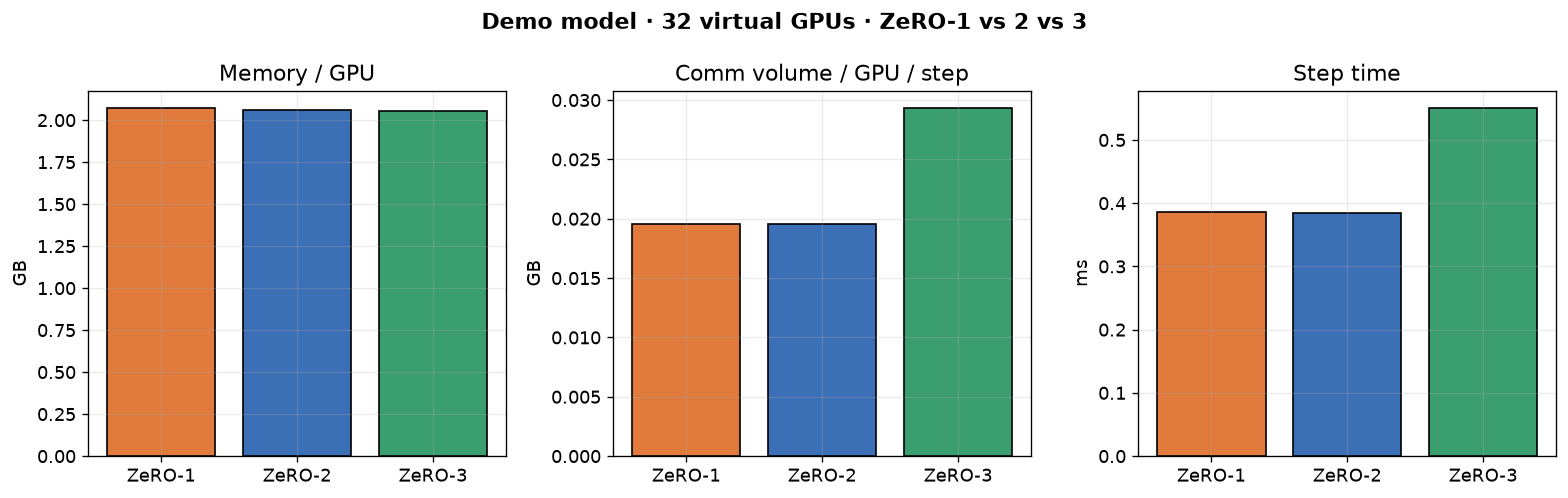

Same FLOPs at every stage: 1.074e+10
ZeRO-3 communicates 1.5× ZeRO-1/2 because it AllGathers parameters in forward as well.


In [6]:
hw = HARDWARE_PROFILES['H100_SXM5']
cluster32 = ClusterConfig(world_size=32, gpus_per_node=8)
flops = calculate_step_compute_flops(demo, activation_checkpointing=True)

comp = []
for stage in (1, 2, 3):
    s = CommunicationProfiler.profile_step_time(
        demo, hw, cluster32, zero_stage=stage, precision='bf16', overlap=True
    )
    m = calculate_model_memory_breakdown(demo, stage, 32, 'bf16')
    psi_gb = demo.total_parameters * 2 / 1024**3
    comp.append({
        'Stage': f'ZeRO-{stage}',
        'FLOPs / step': flops,
        'Compute ms': s['compute_time_ms'],
        'Comm volume GB': s['comm_volume_gb'],
        'Comm = k·Ψ': f'{s["comm_volume_gb"]/psi_gb:.1f} Ψ',
        'Comm ms': s['comm_time_ms'],
        'Step ms (overlap on)': s['step_time_ms'],
        'Comm fraction': s['comm_fraction'],
        'Mem GB / GPU': m['total_gb'],
    })
df_comp = pd.DataFrame(comp)
display(df_comp)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))
stages = df_comp['Stage']
axes[0].bar(stages, df_comp['Mem GB / GPU'], color=['#E07A3D', '#3B6FB6', '#3A9E6F'], edgecolor='black')
axes[0].set_title('Memory / GPU'); axes[0].set_ylabel('GB')
axes[1].bar(stages, df_comp['Comm volume GB'], color=['#E07A3D', '#3B6FB6', '#3A9E6F'], edgecolor='black')
axes[1].set_title('Comm volume / GPU / step'); axes[1].set_ylabel('GB')
axes[2].bar(stages, df_comp['Step ms (overlap on)'], color=['#E07A3D', '#3B6FB6', '#3A9E6F'], edgecolor='black')
axes[2].set_title('Step time'); axes[2].set_ylabel('ms')
fig.suptitle('Demo model · 32 virtual GPUs · ZeRO-1 vs 2 vs 3', fontweight='bold')
plt.tight_layout(); plt.show()

print('Same FLOPs at every stage:', f'{flops:.3e}')
print('ZeRO-3 communicates 1.5× ZeRO-1/2 because it AllGathers parameters in forward as well.')


## What this shows

1. **32 virtual GPUs** exist as ranks + CPU threads. A Colab GPU is optional; the demo runs on CPU.
2. A **demo Transformer** forwards, backwards, and steps on that cluster.
3. **ZeRO-1, ZeRO-2, ZeRO-3** all ran. Memory falls as more state is sharded. Compute FLOPs do not fall; **communication volume and step time** do change (ZeRO-3 is the expensive one at \(3Ψ\)).
4. On a **20B** model the same formulas say ZeRO-1 still OOMs on 80 GB HBM, which is why ZeRO-2/3 exist.
